In [4]:
import piplite
await piplite.install("seaborn")

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("air_quality_dataset.csv")

In [7]:
df.head()

,Date,City,AQI,PM2.5,PM10,Ozone,NO2,CO,SO2,Temperature,Humidity
0,16-10-2024,Los Angeles,128.0,28.78,68.84,58.29,57.56,2.781,17.10,3.4,82.2
1,26-01-2023,Jacksonville,111.0,28.73,61.93,59.00,35.73,NaN,16.33,17.0,36.0
2,09-10-2023,Houston,91.0,20.04,47.10,NaN,43.91,NaN,15.27,1.0,68.6
3,17-08-2023,Chicago,108.0,23.39,47.90,62.85,48.89,NaN,18.49,9.4,85.7
4,15-04-2023,Austin,106.0,26.51,56.08,62.38,NaN,NaN,15.93,17.3,48.7


In [8]:
mean = df["AQI"].mean()

In [9]:
std = df["AQI"].std()

In [10]:
z_score = (df["AQI"]- mean) / std

In [11]:
outliers_z = df[abs(z_score)>3]

In [12]:
print(outliers_z)

            Date          City    AQI  PM2.5    PM10   Ozone    NO2     CO  \
894   30-04-2024   Los Angeles  186.0  35.73   95.40   84.78  46.36  2.800   
1128  27-03-2023    Fort Worth  337.0  28.16   61.16  102.40  44.87  2.010   
1406  25-04-2024   Los Angeles  196.0  40.28   98.00     NaN  54.08  3.141   
1497  28-04-2024   Los Angeles  185.0  43.05   98.58     NaN  51.59  2.592   
1920  29-03-2023   Los Angeles  186.0  42.97   95.24     NaN  57.71  2.392   
1935  12-08-2024       Houston  401.0  27.66   64.97     NaN  49.41  2.583   
2959  18-11-2023  Jacksonville  452.0  20.24   37.97     NaN  43.76  1.523   
3261  04-07-2023        Dallas  371.0  25.78   57.31     NaN  45.81  2.012   
3633  24-03-2024  Jacksonville  331.0  27.22   66.52   81.00  32.91  2.258   
3702  16-05-2024       Houston  188.0  39.74   89.00   84.43  51.04  3.032   
4089  28-03-2024   Los Angeles  187.0  44.46  106.39   97.77  50.38  2.423   
4194  01-07-2024      Columbus  462.0  25.95   62.79   56.10  38

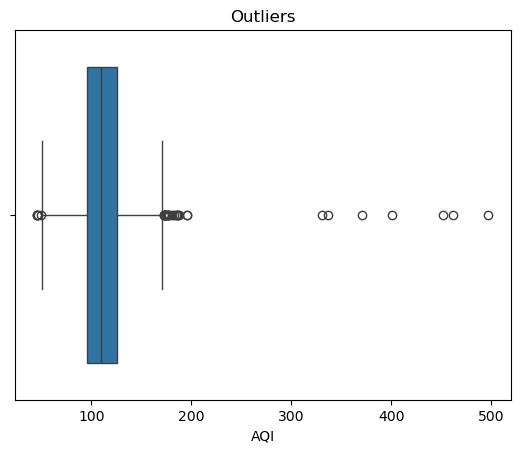

In [13]:
plt.figure()
sns.boxplot(x = df["AQI"])
plt.title("Outliers")
plt.show()

In [15]:
Q1 = df["AQI"].quantile(0.25)
Q3 = df["AQI"].quantile(0.75)
IQR = Q3 - Q1

In [16]:
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [21]:
outliers_iqr = df[(df["AQI"] < lower) | (df["AQI"] > upper)]

In [22]:
print(outliers_iqr)

            Date          City    AQI  PM2.5    PM10   Ozone    NO2     CO  \
8     06-04-2023       Houston  176.0  35.64   70.72  127.53    NaN  2.538   
375   07-07-2024   Los Angeles  173.0  35.11   94.32   55.61  57.64  3.049   
894   30-04-2024   Los Angeles  186.0  35.73   95.40   84.78  46.36  2.800   
999   22-06-2023   Los Angeles  173.0  36.80   93.31   60.10  45.63  2.960   
1128  27-03-2023    Fort Worth  337.0  28.16   61.16  102.40  44.87  2.010   
1163  06-03-2023   Los Angeles  173.0  37.10   89.87  105.98  48.18  2.932   
1235  28-02-2023   Los Angeles  181.0  40.08  102.99   81.56  50.83  2.343   
1406  25-04-2024   Los Angeles  196.0  40.28   98.00     NaN  54.08  3.141   
1497  28-04-2024   Los Angeles  185.0  43.05   98.58     NaN  51.59  2.592   
1875  31-08-2024      San Jose   47.0  13.76   32.52     NaN  39.84    NaN   
1883  28-10-2024      San Jose   50.0  17.10   34.67     NaN  35.30  2.170   
1920  29-03-2023   Los Angeles  186.0  42.97   95.24     NaN  57

In [23]:
median = df["AQI"].median()
mad = np.median(np.abs(df["AQI"]- median))
modified_z = 0.6745 * (df["AQI"]- median)/ mad 
outliers_mod = df[abs(modified_z) > 3.5]
print(outliers_mod)

Empty DataFrame
Columns: [Date, City, AQI, PM2.5, PM10, Ozone, NO2, CO, SO2, Temperature, Humidity]
Index: []


In [24]:
print("Z-score:", len(outliers_z))
print("IQR:", len(outliers_iqr))
print("Modified Z:", len(outliers_mod))

Z-score: 14
IQR: 34
Modified Z: 0
